In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from keras.models import Sequential #Removed 'tensorflow' from the code since it got updated to Keras 3.0
from keras.layers import Input, Dense #Removed 'tensorflow' from the code since it got updated to Keras 3.0
import matplotlib.pyplot as plt
import seaborn as sns
import os 



--- Task 1: Dataset Understanding ---
Shape: (2000, 17)

Data Types:
 customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object 

Missing Values:
 customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charg

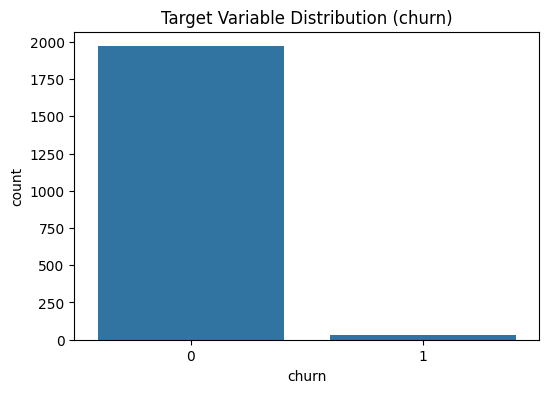

In [2]:
# Task 1: Dataset Understanding
# Loading the dataset
df = pd.read_csv('customer_churn_nn.csv')

print("--- Task 1: Dataset Understanding ---")
print(f"Shape: {df.shape}\n")
print("Data Types:\n", df.dtypes, "\n")
print("Missing Values:\n", df.isnull().sum(), "\n")
print("Basic Statistical Summary:\n", df.describe(), "\n")
print("Target Variable Distribution (churn):\n", df['churn'].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)
plt.title('Target Variable Distribution (churn)')
plt.savefig('results/target_distribution.png')
plt.show()



In [3]:
#Task 2: Data Preprocessing
print ("--- Task 2: Data Preprocessing ---")
#dropping ID column as it is not a predictor
df = df.drop('customer_id', axis=1)
#Seperating features and target variable
X = df.drop('churn', axis=1)
y = df['churn']
#Defining categorical and numerical columns
categorical_cols = ['region', 'plan_type', 'payment_method']
numerical_cols = ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 
                  'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 
                  'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'referral_count']
# Creating preprocessor: Standardize numerical, One-Hot Encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])
# Applying preprocessing
X_preprocessed = preprocessor.fit_transform(X)

#Train-test-split(80 training, 20 testing)
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y , test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")



--- Task 2: Data Preprocessing ---
Training features shape: (1600, 21)
Testing features shape: (400, 21)


Base Model = Train Accuracy: 0.9850, Train Loss: 0.0626
Base Model - Test Accuracy: 0.9825, Test Loss: 0.0752
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Confusion Matrix:
 [[393   0]
 [  7   0]]


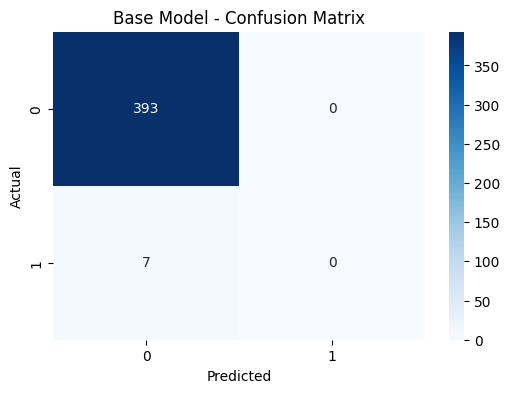

In [14]:
#Task 3 & 4: Model building and training
def build_model(hidden_layers=1, neurons=32, activation='relu', learning_rate=0.001):
    model = Sequential()
    #Defining the input shape first
    model.add(Input(shape=(X_train.shape[1],)))
    #First hidden layer
    model.add(Dense(neurons, activation=activation))
    #Adding additional hidden layers
    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons, activation=activation))

    #Output layer(1 neuron, sigmoid activation for binary classification)
    model.add(Dense(1, activation='sigmoid'))

    #Compiling the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model
#Building and training the base model
base_model = build_model()
history = base_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=0)
#Evaluating
train_loss, train_acc = base_model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = base_model.evaluate(X_test, y_test, verbose=0)
print(f"Base Model = Train Accuracy: {train_acc:.4f}, Train Loss: {train_loss:.4f}")
print(f"Base Model - Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

#Confusion Matrix
y_pred = (base_model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Base Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('results/base_model_confusion_matrix.png')
plt.show()





--- Task 5: Hyperparameter Experimentation ---
                   Experiment  Hidden Layers  Neurons Activation      LR  Epochs  Batch Size  Train Acc  Test Acc
0                  Base Model              1       32       relu  0.0010      20          32     0.9850    0.9825
1       Exp 1: Deeper Network              3       64       relu  0.0010      20          32     1.0000    0.9750
2  Exp 2: Lower Learning Rate              1       32       relu  0.0001      50          32     0.9850    0.9825
3      Exp 3: Tanh Activation              2       32       tanh  0.0010      20          16     0.9862    0.9825


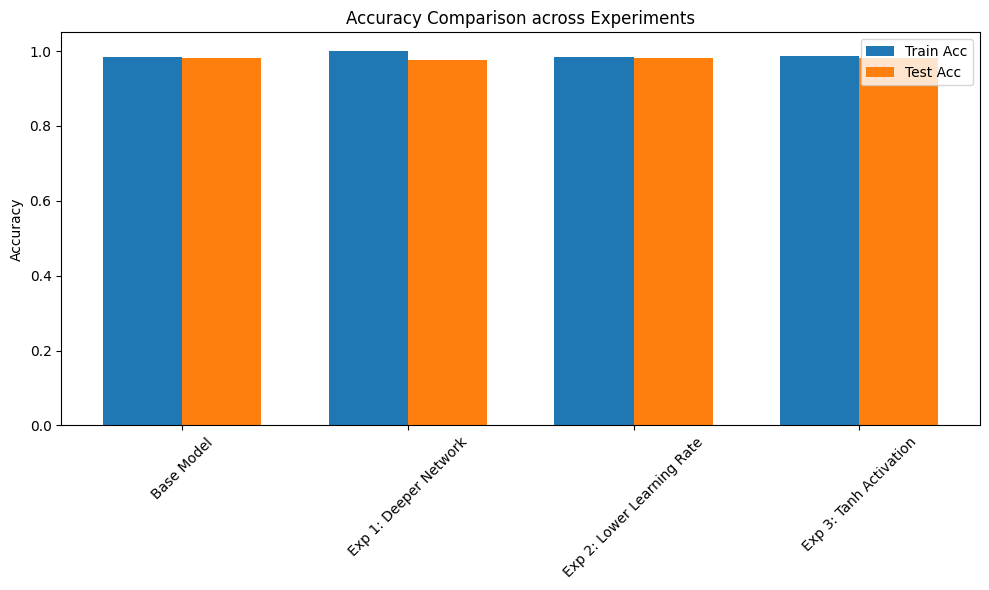

In [15]:
#Hyperparameter Experimenting
print("--- Task 5: Hyperparameter Experimentation ---")

#Defining 3 new experiments
experiments = [
    {"name": "Exp 1: Deeper Network", "hidden_layers": 3, "neurons": 64, "activation":"relu", "lr": 0.001, "epochs": 20, "batch_size": 32},
    {"name": "Exp 2: Lower Learning Rate", "hidden_layers": 1, "neurons": 32, "activation":"relu", "lr": 0.0001, "epochs": 50, "batch_size": 32},
    {"name": "Exp 3: Tanh Activation", "hidden_layers": 2, "neurons": 32, "activation":"tanh", "lr": 0.001, "epochs": 20, "batch_size": 16}
]

#Storing results
results = []
results.append({
    "Experiment": "Base Model",
    "Hidden Layers": 1, "Neurons":32, "Activation": "relu", "LR":0.001, "Epochs": 20, "Batch Size": 32, 
    "Train Acc": round(train_acc, 4), "Test Acc": round(test_acc, 4)
})

#Run experiments
for exp in experiments:
    model = build_model(hidden_layers=exp['hidden_layers'], neurons=exp['neurons'], activation=exp['activation'], learning_rate=exp['lr'])
    model.fit(X_train, y_train, epochs=exp['epochs'], batch_size=exp['batch_size'], verbose=0)
    t_loss, t_acc = model.evaluate(X_train, y_train, verbose=0)
    te_loss, te_acc = model.evaluate(X_test, y_test, verbose=0)

    results.append({
        "Experiment": exp['name'],
        "Hidden Layers": exp['hidden_layers'], "Neurons": exp['neurons'], "Activation": exp['activation'],
        "LR": exp['lr'], "Epochs": exp['epochs'], "Batch Size": exp['batch_size'],
        "Train Acc": round(t_acc, 4), "Test Acc": round(te_acc, 4)
})
    #Saving results to a csv file
results_df = pd.DataFrame(results)
print(results_df.to_string())
results_df.to_csv('results/model_comparison_table.csv', index=False)

#plotting accuracy comparisons
plt.figure(figsize=(10,6))
x_labels = results_df['Experiment']
x = np.arange(len(x_labels))
width = 0.35
plt.bar(x - width/2, results_df['Train Acc'], width, label='Train Acc')
plt.bar(x + width/2, results_df['Test Acc'], width, label='Test Acc')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison across Experiments')
plt.xticks(x, x_labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png')
plt.show()